<center>
<img src="https://laelgelcpublic.s3.sa-east-1.amazonaws.com/lael_50_years_narrow_white.png.no_years.400px_96dpi.png" width="300" alt="LAEL 50 years logo">
<h3>APPLIED LINGUISTICS GRADUATE PROGRAMME (LAEL)</h3>
</center>
<hr>

# Corpus Linguistics - Study 1 - Phase 1 - Leticia

This document aims to gather data for project planning.

## Determine speakers and define the AI speaker

Define the AI speaker as `S0999` since the highest speaker id is `S0691`.

In [1]:
from pathlib import Path
import xml.etree.ElementTree as ET

xml_dir = Path("corpus/bnc2014spoken-xml/spoken/untagged")
speakers = set()

for xml_file in xml_dir.glob("*.xml"):
    root = ET.parse(xml_file).getroot()
    for elem in root.findall(".//list_speakers"):
        if elem.text:
            speakers.update(elem.text.split())

print(", ".join(sorted(speakers)))


S0001, S0002, S0003, S0004, S0005, S0006, S0007, S0008, S0009, S0010, S0011, S0012, S0013, S0014, S0015, S0016, S0017, S0018, S0019, S0020, S0021, S0022, S0023, S0024, S0025, S0026, S0027, S0028, S0029, S0030, S0031, S0032, S0033, S0034, S0035, S0036, S0037, S0038, S0039, S0040, S0041, S0042, S0043, S0044, S0045, S0046, S0047, S0048, S0049, S0050, S0051, S0052, S0053, S0054, S0055, S0056, S0057, S0058, S0059, S0060, S0061, S0062, S0063, S0064, S0065, S0066, S0067, S0068, S0069, S0070, S0071, S0072, S0073, S0074, S0075, S0076, S0077, S0078, S0079, S0080, S0081, S0082, S0083, S0084, S0085, S0086, S0087, S0088, S0089, S0090, S0091, S0092, S0093, S0094, S0095, S0096, S0097, S0098, S0099, S0100, S0101, S0102, S0103, S0104, S0105, S0106, S0107, S0108, S0109, S0110, S0113, S0114, S0115, S0116, S0117, S0118, S0119, S0120, S0121, S0122, S0123, S0124, S0125, S0126, S0127, S0128, S0129, S0130, S0131, S0132, S0133, S0134, S0135, S0136, S0137, S0138, S0139, S0140, S0141, S0142, S0143, S0144, S0145,

## Detemine the speaker with the highest number of turns in each conversation

In [7]:
import pandas as pd
from collections import Counter

rows = []

for xml_file in xml_dir.glob("*.xml"):
    root = ET.parse(xml_file).getroot()
    text_id = root.get("id", xml_file.stem)
    turns = root.findall(".//body/u")
    total_turns = len(turns)
    speaker_counts = Counter(
        u.get("who") for u in turns
        if u.get("who")
    )

    if speaker_counts:
        top_talker, top_talker_turns = sorted(
            speaker_counts.items(),
            key=lambda item: (-item[1], item[0])
        )[0]
    else:
        top_talker, top_talker_turns = None, 0

    rows.append(
        {
            "text_id": text_id,
            "total_turns": total_turns,
            "top_talker": top_talker,
            "top_talker_turns": top_talker_turns,
        }
    )

turns_df = pd.DataFrame(rows).sort_values("text_id").reset_index(drop=True)
turns_df.to_json("top_talkers.ndjson", orient="records", lines=True)

turns_df


,text_id,total_turns,top_talker,top_talker_turns
0,S23A,4041,S0094,1203
1,S24A,127,S0261,63
2,S24D,455,S0653,200
3,S24E,709,S0520,283
4,S263,3160,S0590,1086
...,...,...,...,...
1246,SZVB,1463,S0517,730
1247,SZVC,798,S0325,398
1248,SZW4,479,S0510,238
1249,SZXQ,838,S0058,411


## Detemine the speaker with the highest number of turns overall

In [3]:
peak_conversation = turns_df.loc[turns_df["total_turns"].idxmax(), ["text_id", "total_turns"]]
top_top_talker = turns_df.loc[turns_df["top_talker_turns"].idxmax(), ["text_id", "top_talker", "top_talker_turns"]]

print(
    f"Conversation with peak number of turns: {peak_conversation['text_id']} ({peak_conversation['total_turns']} turns)")
print(
    f"Top top talker: {top_top_talker['top_talker']} in conversation {top_top_talker['text_id']} ({top_top_talker['top_talker_turns']} turns)")


Conversation with peak number of turns: SUVQ (16574 turns)
Top top talker: S0198 in conversation SUVQ (4601 turns)


## Determine the conversation with the least number of turns

In [6]:
least_conversation = turns_df.loc[turns_df["total_turns"].idxmin(), ["text_id", "total_turns", "top_talker"]]

print(
    f"Conversation with the least number of turns: {least_conversation['text_id']} "
    f"({least_conversation['total_turns']} turns); top talker: {least_conversation['top_talker']}"
)


Conversation with the least number of turns: SEV9 (67 turns); top talker: S0202


## Determine the total number of turns produced by the top talkers

In [4]:
total_top_talker_turns = turns_df["top_talker_turns"].sum()
print(f"Total number of turns produced by the top talkers: {total_top_talker_turns}")


Total number of turns produced by the top talkers: 510697


## Import the dataset into DataFrames and save them as NDJSON files

Write the `01_import_bnc2014sp.py` programme according to the following specifications:

1. Load the NDJSON file containing top-talker information into the `df_top_talkers` DataFrame.
   - Required columns: `text_id`, `top_talker`

2. Parse all XML files in `corpus/bnc2014spoken-xml/spoken/untagged/`.

3. Create `df_bnc2014sp_header` with one row per XML file.
   - Include `text_id`
   - Include one column for each direct child tag of `<header>`, excluding `<speakerInfo>`
   - Normalize text content
   - Store missing values as null

4. Create the speaker information datasets from `<speakerInfo>`:

   a. Create `df_bnc2014sp_speaker_info_occurrences` with:
   - `text_id`
   - `speaker_id`
   - one column per corresponding speaker metadata tag

   b. Create `df_bnc2014sp_speakers` as a speaker database with:
   - `speaker_id`
   - one consolidated value per speaker metadata field

   During parsing:
   - add new speakers when first encountered
   - if an existing speaker is found, compare metadata with previous occurrences
   - log any mismatches
   - preserve occurrence-level records
   - keep one consolidated row per `speaker_id` in the speaker database

   Sort the speaker database by `speaker_id` ascending.

5. Create `df_bnc2014sp_conversation` with one row per utterance in `<body>`.
   - Include `text_id`
   - Include a sequential turn index
   - Include `speaker_id`
   - Include utterance text
   - Include relevant utterance attributes
   - Add `top_talker` with value `Yes` if `speaker_id` equals the top talker for that `text_id`, otherwise `No`

6. Save the DataFrames in `corpus/01_bnc2014sp_dataset/` as NDJSON files using their names without the `df_` prefix.
   - Use record-oriented NDJSON format
   - UTF-8 encoding

7. Log processing progress, parse issues, and speaker metadata mismatches.

## Descriptive statistics of the utterances

In [8]:
"""Load the BNC 2014 spoken conversation dataset into a DataFrame and display it."""

df_bnc2014sp_conversation = pd.read_json(
    "corpus/01_bnc2014sp_dataset/bnc2014sp_conversation.ndjson",
    orient="records",
    lines=True
)

df_bnc2014sp_conversation


,text_id,turn_n,speaker_id,utterance,top_talker,trans,whoConfidence
0,S23A,1,S0094,words,Yes,None,None
1,S23A,2,S0095,it's a games word? like a computer games word?,No,None,None
2,S23A,3,S0032,yeah yeah,No,None,None
3,S23A,4,S0095,oh oh that's nice,No,None,None
4,S23A,5,S0032,I it's something I have really heard z-buffer ...,No,overlap,None
...,...,...,...,...,...,...,...
1248105,SZYV,316,S0432,but anyway erm he was like Sha Li that's reall...,No,None,None
1248106,SZYV,317,S0428,no I'm quite happy with Sha Li,Yes,None,None
1248107,SZYV,318,S0432,I'll just stick with it yeah this was like hal...,No,overlap,None
1248108,SZYV,319,S0428,yeah got to change my name that's crazy isn't ...,Yes,overlap,None


In [9]:
"""Insert an utterance word count column immediately after the utterance column."""

utterance_col_idx = df_bnc2014sp_conversation.columns.get_loc("utterance")
df_bnc2014sp_conversation.insert(
    utterance_col_idx + 1,
    "utterance_word_count",
    df_bnc2014sp_conversation["utterance"].fillna("").str.split().str.len()
)

df_bnc2014sp_conversation


,text_id,turn_n,speaker_id,utterance,utterance_word_count,top_talker,trans,whoConfidence
0,S23A,1,S0094,words,1,Yes,None,None
1,S23A,2,S0095,it's a games word? like a computer games word?,9,No,None,None
2,S23A,3,S0032,yeah yeah,2,No,None,None
3,S23A,4,S0095,oh oh that's nice,4,No,None,None
4,S23A,5,S0032,I it's something I have really heard z-buffer ...,13,No,overlap,None
...,...,...,...,...,...,...,...,...
1248105,SZYV,316,S0432,but anyway erm he was like Sha Li that's reall...,29,No,None,None
1248106,SZYV,317,S0428,no I'm quite happy with Sha Li,7,Yes,None,None
1248107,SZYV,318,S0432,I'll just stick with it yeah this was like hal...,34,No,overlap,None
1248108,SZYV,319,S0428,yeah got to change my name that's crazy isn't ...,14,Yes,overlap,None


In [10]:
utterance_word_count_stats = df_bnc2014sp_conversation["utterance_word_count"].describe(
    percentiles=[0.25, 0.5, 0.75]
)
utterance_word_count_stats

count    1.248110e+06
mean     8.262278e+00
std      1.216094e+01
min      0.000000e+00
25%      1.000000e+00
50%      5.000000e+00
75%      1.000000e+01
max      9.590000e+02
Name: utterance_word_count, dtype: float64

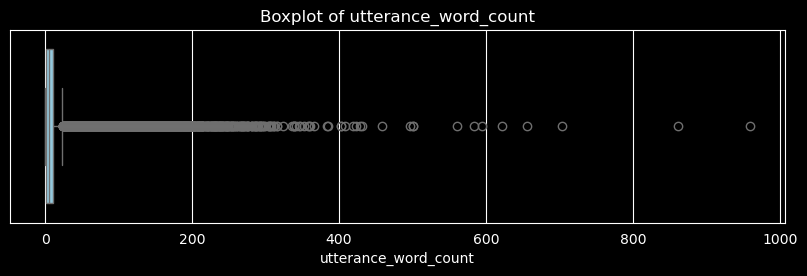

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 2.5))
sns.boxplot(x=df_bnc2014sp_conversation["utterance_word_count"], color="skyblue")
plt.title("Boxplot of utterance_word_count")
plt.xlabel("utterance_word_count")
plt.show()


### Slice of the DataFrame with the 1700 longest utterances produced by top talkers

In [12]:
"""Create a DataFrame with the 1,700 longest utterances produced by top talkers."""

top_talker_longest_1700_df = (
    df_bnc2014sp_conversation.loc[df_bnc2014sp_conversation["top_talker"].eq("Yes")]
    .sort_values(
        by=["utterance_word_count", "text_id", "turn_n"],
        ascending=[False, True, True]
    )
    .head(1700)
    .reset_index(drop=True)
)

top_talker_longest_1700_df


,text_id,turn_n,speaker_id,utterance,utterance_word_count,top_talker,trans,whoConfidence
0,SXR9,643,S0405,I dunno if you wanna was after the American le...,861,Yes,None,None
1,S8LS,1086,S0060,yeah but unfortunately these days any bit of s...,561,Yes,None,None
2,SVLK,10,S0310,and then I went to erm I suppose when they wer...,501,Yes,None,None
3,SN64,2051,S0590,yes yes labels yes well on the other side they...,459,Yes,None,None
4,SJJK,132,S0618,which I think is sort of my higher self saying...,431,Yes,None,None
...,...,...,...,...,...,...,...,...
1695,SR8V,39,S0610,it's just a case really of getting whatever's ...,94,Yes,None,None
1696,SU6F,687,S0281,and they di same thing happened last week and ...,94,Yes,None,None
1697,SUHT,120,S0262,yeah yeah I mean I've always found to be very ...,94,Yes,overlap,None
1698,SV49,428,S0054,or not even more extreme just he's actually al...,94,Yes,overlap,None


In [16]:
"""Create a set of unique text IDs from the 1,700 longest top-talker utterances, print them sorted alphabetically, and print the count."""

text_ids_top_talker_longest_1700 = set(top_talker_longest_1700_df["text_id"].dropna().unique())
sorted_text_ids_top_talker_longest_1700 = sorted(text_ids_top_talker_longest_1700)
print(", ".join(sorted_text_ids_top_talker_longest_1700))
print(f"Count: {len(sorted_text_ids_top_talker_longest_1700)}")


S24A, S24E, S263, S28F, S29X, S2AX, S2C9, S2FQ, S2JK, S2K7, S2T6, S2TC, S2UJ, S2UT, S2XV, S32W, S32Y, S35K, S36Z, S37F, S382, S3C6, S3DA, S3JF, S3KY, S3LE, S3M4, S3QD, S3RZ, S3YZ, S457, S46J, S46Q, S4C2, S4D8, S4K7, S4L9, S4MF, S4MV, S4RF, S4TV, S4VJ, S4W8, S4WJ, S4YQ, S4ZA, S4ZT, S539, S55M, S59W, S5B4, S5B6, S5DJ, S5ER, S5HH, S5JX, S5LP, S5P8, S5QP, S5XD, S5YC, S63L, S64H, S66E, S68E, S69V, S6A5, S6A7, S6AP, S6AZ, S6GC, S6J2, S6JL, S6JP, S6MQ, S6PD, S6Q6, S6R4, S6W8, S6YA, S72E, S72Q, S73U, S74A, S784, S78P, S7A6, S7FK, S7GJ, S7GW, S7HR, S7JG, S7JH, S7JS, S7K2, S7KD, S7KK, S7LN, S7MF, S7NH, S7NV, S7PU, S7QU, S7QY, S7RW, S7S2, S7SU, S7SX, S7SZ, S7VD, S7WR, S7Z8, S8B9, S8BQ, S8CB, S8CV, S8CW, S8J6, S8LG, S8LS, S8NX, S8PT, S8Q3, S8RY, S8S2, S8U5, S8VZ, S8WS, S8X7, S8XE, S8YL, S94Z, S95D, S968, S97B, S9B9, S9E6, S9EP, S9ER, S9GP, S9RV, S9UA, S9VA, S9VB, S9WB, S9WZ, S9X9, S9YG, S9ZP, SA2J, SA4W, SA69, SA6K, SA88, SAAB, SAAF, SAB7, SABT, SADE, SAG4, SAMQ, SAQD, SAR5, SASC, SASQ, SAT9, SAUJ